# Predicting Bank Customer Churn

## Project Overview

This notebook presents an end-to-end customer churn prediction project using bank customer data. It combines exploratory data analysis and classification modelling to identify which customers are most likely to leave the bank.

## Business Context

Customer churn affects revenue, customer lifetime value, and retention costs. A well-performing churn model helps the business identify at-risk customers early and respond with targeted retention strategies.

## Objectives

- Understand the dataset structure and quality.
- Explore key features related to churn.
- Build and compare classification models.
- Interpret the results in a business context.
- Recommend the most suitable model for churn prediction.

## Dataset Features

- `customer_id`: unique customer identifier
- `credit_score`: customer credit score
- `country`: country of residence
- `gender`: customer gender
- `age`: customer age
- `tenure`: years with the bank
- `balance`: account balance
- `products_number`: number of bank products held
- `credit_card`: whether the customer has a credit card (`1` = yes, `0` = no)
- `active_member`: whether the customer is an active member (`1` = yes, `0` = no)
- `estimated_salary`: estimated annual salary
- `churn`: target variable (`1` = churned, `0` = retained)

## Workflow

1. Load and inspect the dataset.
2. Perform exploratory data analysis.
3. Prepare the data for modelling.
4. Train and compare classification models.
5. Summarise insights and recommendations.

## Step 1: Load the Dataset

The dataset is loaded from Azure Blob Storage. For GitHub readiness and security, the connection string should be stored as an environment variable instead of being written directly in the notebook.


In [6]:
import os
import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

# Store the Azure connection string in an environment variable before running this cell.
connect_str = os.getenv('AZURE_STORAGE_CONNECTION_STRING')
if not connect_str:
    raise ValueError(
        'Set the AZURE_STORAGE_CONNECTION_STRING environment variable before running this notebook.'
    )

container_name = 'businesscases'
blob_name = 'Bank_Customer_Churn_Prediction.csv'

blob_service_client = BlobServiceClient.from_connection_string(connect_str)
container_client = blob_service_client.get_container_client(container_name)
blob_client = container_client.get_blob_client(blob_name)

blob_data = blob_client.download_blob()
csv_content = blob_data.readall().decode('utf-8')

df = pd.read_csv(StringIO(csv_content))
df.head()


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

The output confirms that the dataset loaded successfully and that the columns are available for analysis.

**Key points**

- The dataset includes a mix of demographic, financial, and behavioural variables.
- The target variable, `churn`, is available for supervised classification.
- The project can proceed to data quality checks and exploratory analysis.

</div>


### Full Dataset Preview

The table below displays the dataset in tabular form for closer inspection.


In [7]:
display(df)

<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

Reviewing the full table helps confirm the column names, data layout, and the general form of the observations before analysis begins.

**Key points**

- Feature names are clear and consistent.
- The dataset is structured appropriately for analysis in pandas.
- The preview supports validation before modelling.

</div>


## Step 2: Exploratory Data Analysis

### Task 2.1: Check for Missing Values and Data Types

Before building any model, it is important to confirm that the data is complete and stored in the correct format.


In [8]:
# Check for missing values
print(f"Missing values in each column:\n{df.isnull().sum()}")

# Check the data types of each column
print(f"Data types:\n{df.dtypes}")


Missing values in each column:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64
Data types:
customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object


<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

This output shows whether any columns contain missing values and whether the data types align with expectations.

**Key points**

- Missing values can be identified and addressed before modelling.
- Data types confirm which variables are numeric and which are categorical.
- This step reduces the risk of errors later in the workflow.

</div>


### Task 2.2: Summary Statistics

Summary statistics provide a quick overview of the centre, spread, and range of the numeric variables.


In [9]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
summary_stats = numeric_df.describe()
summary_stats 

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

The summary table helps identify typical values, extreme values, and possible outliers across the numeric features.

**Key points**

- Numeric variables differ in scale and distribution.
- The output provides useful context before visual analysis.
- It highlights features that may deserve closer attention in EDA.

</div>


### Task 2.3: Explore Key Feature Distributions

The following visualisations focus on important variables related to customer churn.


In [10]:
# Optional: run this only if seaborn is not already installed in your environment.
# %pip install seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 9.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


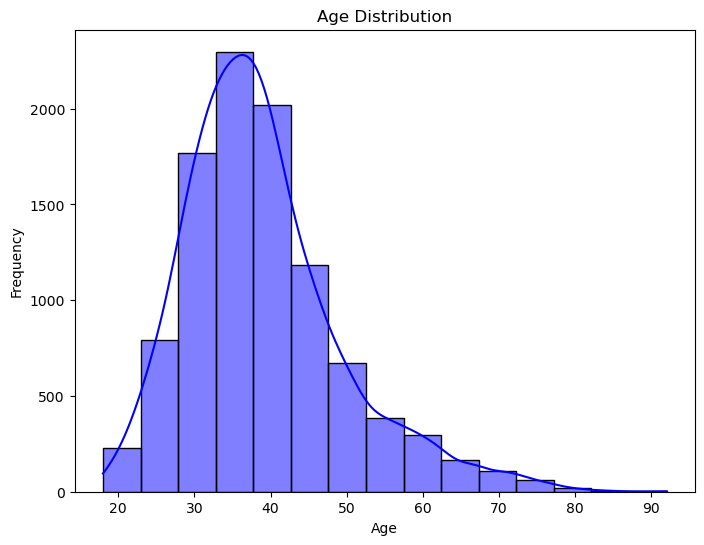

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Age distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['age'], bins=15, kde=True, color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()




<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

The age distribution is right-skewed, with most customers concentrated around the 30 to 40 age range and fewer customers at older ages.

**Key points**

- The customer base is weighted toward younger and middle-aged customers.
- Age may be a meaningful segmentation variable.
- Older age groups may require targeted churn monitoring.

</div>


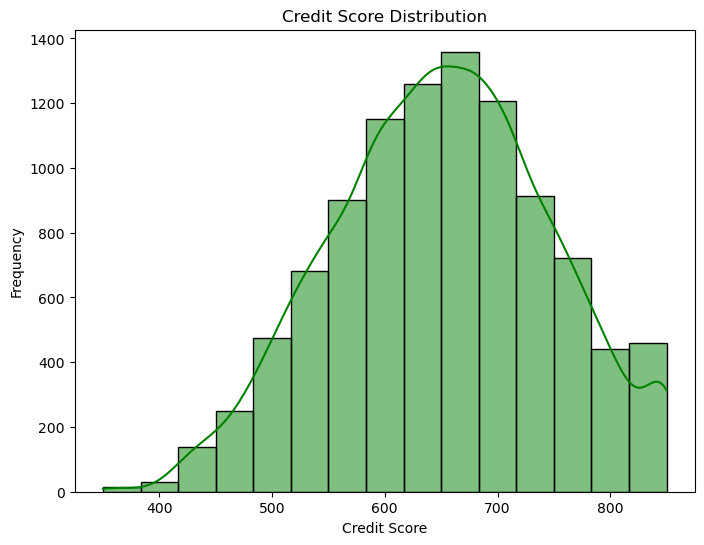

In [12]:
# Credit score distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['credit_score'], bins=15, kde=True, color='green')
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()



<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

Credit scores are distributed fairly evenly around the middle range, without strong skew toward very low or very high scores.

**Key points**

- Most customers have moderate credit scores.
- Credit score alone is unlikely to explain churn strongly.
- It may be more useful when combined with behavioural features.

</div>


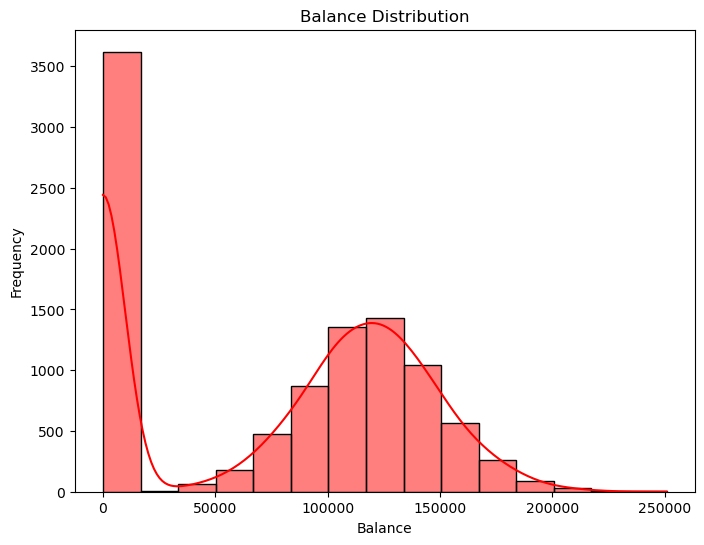

In [13]:
# Balance distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['balance'], bins=15, kde=True, color='red')
plt.title('Balance Distribution')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()



<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

The balance distribution is highly uneven, with one group clustered at zero balance and another group holding much higher balances.

**Key points**

- The dataset appears to contain distinct customer segments.
- High-balance customers may represent a higher business value.
- Churn among high-balance customers may be especially costly.

</div>


/tmp/ipykernel_117/981058916.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='Set1')


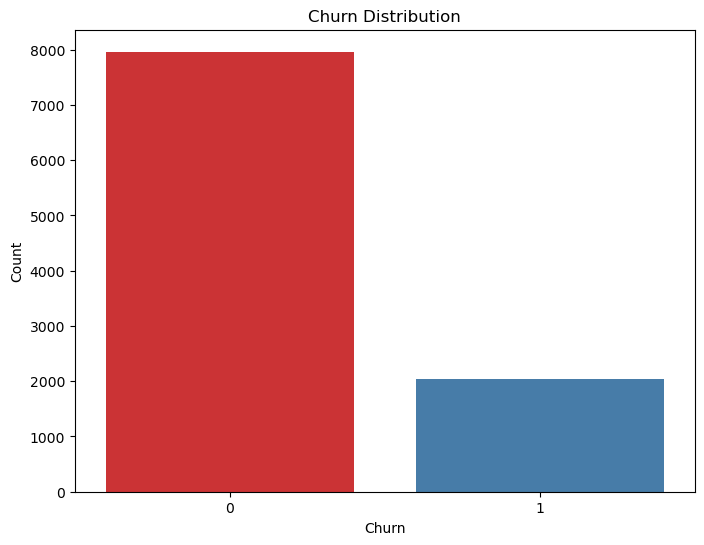

In [14]:
# Churn distribution (target variable)
plt.figure(figsize=(8, 6))
sns.countplot(x='churn', data=df, palette='Set1')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

The churn distribution is imbalanced, with many more retained customers than churned customers.

**Key points**

- The target variable is not evenly distributed.
- Accuracy alone may be misleading in this problem.
- Metrics such as recall, precision, and the confusion matrix are important.

</div>


### Task 2.4: Correlation Heatmap

The correlation heatmap shows the strength of linear relationships between numeric variables.


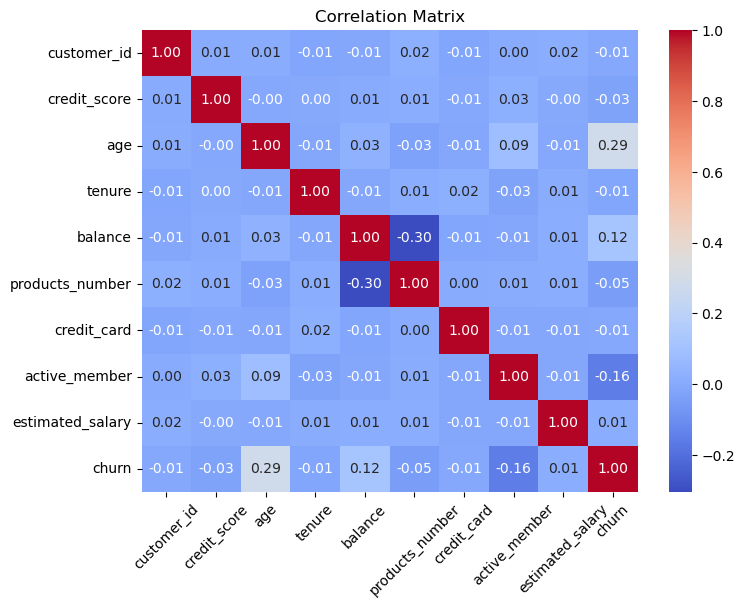

In [15]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.xticks(rotation=45)
plt.show()

<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

Most correlations are weak, which suggests churn is influenced by a combination of variables rather than a single dominant feature.

**Key points**

- `age` shows one of the strongest positive relationships with churn.
- `active_member` has a negative relationship with churn, suggesting engaged customers are less likely to leave.
- `balance` has a weak positive relationship with churn.

</div>


## Step 3: Model Training

### Task 3.1: Prepare Data for Training

The categorical variables must be encoded so they can be used by the machine learning models.


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns so they can be used in the models.
label_encoder = LabelEncoder()
df['gender'] = label_encoder.fit_transform(df['gender'])
df['country'] = label_encoder.fit_transform(df['country'])

# Features (X) and target (y)
X = df[['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'gender', 'country']]
y = df['churn']


<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

The feature matrix and target variable are now separated, and categorical values have been converted into a numerical form.

**Key points**

- The dataset is now in a format suitable for scikit-learn models.
- Gender and country have been encoded for model training.
- The selected features combine customer profile, behaviour, and financial information.

</div>


### Task 3.2: Split Data into Training and Test Sets

The data is divided into training and test sets so the models can be evaluated on unseen examples.


In [17]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set size: {X_train.shape[0]} rows')
print(f'Test set size: {X_test.shape[0]} rows')


<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

The output confirms that the dataset has been separated into training and test subsets.

**Key points**

- The training set is used to learn model patterns.
- The test set is reserved for evaluation.
- This improves confidence that the final performance reflects real predictive ability.

</div>


### Task 3.3: Train a Logistic Regression Model

Logistic Regression is used as the baseline model for this binary classification problem.


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Initialize Logistic Regression model
log_reg_model = LogisticRegression()

# Train the model
log_reg_model.fit(X_train, y_train)

# Predict on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {log_reg_accuracy}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log_reg)



/home/trusted-service-user/jupyter-env/python3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


🏃 View run sincere_glove_5j84z97q at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/dc706e34-2057-4e65-9e86-d72310db9dba/#/experiments/77cdc8e6-f795-4093-aeb3-f472839cecc7/runs/9a3928c8-ec95-4c9b-8961-b62510ed5ee6
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/dc706e34-2057-4e65-9e86-d72310db9dba/#/experiments/77cdc8e6-f795-4093-aeb3-f472839cecc7


Logistic Regression Accuracy: 0.799


<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

Logistic Regression provides a baseline accuracy score that can be used to compare with more advanced models.

**Key points**

- The model is simple and interpretable.
- Its performance should be judged alongside class imbalance.
- Baseline performance helps show whether more complex models add value.

</div>


### Logistic Regression Prediction Table

The following table compares actual churn outcomes with the Logistic Regression predictions.


In [19]:
results_df = pd.DataFrame({
    'Actual Churn': y_test,
    'Predicted Churn (Logistic Regression)': y_pred_log_reg})
display(results_df)

<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

This table allows row-by-row inspection of correct and incorrect predictions.

**Key points**

- True positives and false negatives can be reviewed directly.
- The table makes model behaviour easier to explain to readers.
- It supports deeper interpretation beyond a single summary metric.

</div>


### Logistic Regression Confusion Matrix

The confusion matrix gives a clearer view of classification performance across both churn classes.


In [20]:
# Confusion matrix for Logistic Regression
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {log_reg_accuracy}")

cm = confusion_matrix(y_test, y_pred_log_reg, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=['Actual: 0 (No Churn)', 'Actual: 1 (Churn)'],
    columns=['Predicted: 0 (No Churn)', 'Predicted: 1 (Churn)']
)
print(cm_df)


Logistic Regression Accuracy: 0.799
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     1567                       40
Actual: 1 (Positive)                      362                       31


<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

The confusion matrix shows that Logistic Regression correctly identifies many non-churn customers, but misses a large number of actual churn cases.

**Key points**

- The model performs better on retained customers than churned customers.
- False negatives are a major concern in a churn prediction task.
- The accuracy score alone overstates the usefulness of this model.

</div>


### Understanding the Confusion Matrix

A confusion matrix compares actual outcomes with predicted outcomes:

| Actual \ Predicted | Predicted: No Churn | Predicted: Churn |
| --- | --- | --- |
| **Actual: No Churn** | True Negative (TN) | False Positive (FP) |
| **Actual: Churn** | False Negative (FN) | True Positive (TP) |

Accuracy is calculated as:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

This metric is useful, but it should be interpreted carefully when classes are imbalanced.


### Task 3.4: Train a Random Forest Classifier

Random Forest is a more flexible model that can capture non-linear relationships and interactions between features.


In [21]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy}")

# Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])
cm_rf = pd.DataFrame(cm_rf,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
print(cm_rf)


🏃 View run yellow_kettle_gy96s1ss at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/dc706e34-2057-4e65-9e86-d72310db9dba/#/experiments/77cdc8e6-f795-4093-aeb3-f472839cecc7/runs/3d12040b-7e21-4d32-a2f6-493fafe339c2
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/dc706e34-2057-4e65-9e86-d72310db9dba/#/experiments/77cdc8e6-f795-4093-aeb3-f472839cecc7


Random Forest Accuracy: 0.867
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     1554                       53
Actual: 1 (Positive)                      213                      180


<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

The Random Forest model improves on the baseline and identifies more churn cases while maintaining strong overall accuracy.

**Key points**

- Random Forest performs better than Logistic Regression on this dataset.
- It is more effective at identifying churners.
- The model is better suited to a real-world retention use case.

</div>


### Task 3.5: Tune the Random Forest Model

To assess whether the model can be improved further, the number of trees is increased from 100 to 150 and then to 300.


### Tuning Focus: `n_estimators`

The `n_estimators` parameter controls how many decision trees are included in the Random Forest.

Increasing the number of trees can improve stability and performance, but it also increases computation time. The goal is to find the best balance between accuracy and efficiency.


In [22]:
# Tune Random Forest with 150 estimators
rf_model_tuned_150 = RandomForestClassifier(n_estimators=150, random_state=42)
rf_model_tuned_150.fit(X_train, y_train)

y_pred_rf_tuned_150 = rf_model_tuned_150.predict(X_test)
rf_tuned_accuracy_150 = accuracy_score(y_test, y_pred_rf_tuned_150)
print(f"Random Forest (150 estimators) Accuracy: {rf_tuned_accuracy_150}")

cm_rf_tuned_150 = confusion_matrix(y_test, y_pred_rf_tuned_150, labels=[0, 1])
cm_rf_tuned_150 = pd.DataFrame(
    cm_rf_tuned_150,
    index=['Actual: 0 (No Churn)', 'Actual: 1 (Churn)'],
    columns=['Predicted: 0 (No Churn)', 'Predicted: 1 (Churn)']
)
print(cm_rf_tuned_150)


🏃 View run heroic_peach_2476kl1q at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/dc706e34-2057-4e65-9e86-d72310db9dba/#/experiments/77cdc8e6-f795-4093-aeb3-f472839cecc7/runs/92e2c924-58e6-49d4-8913-3ea5ca5235bd
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/dc706e34-2057-4e65-9e86-d72310db9dba/#/experiments/77cdc8e6-f795-4093-aeb3-f472839cecc7


Random Forest (Tuned 150 n estimators) Accuracy: 0.8685
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     1555                       52
Actual: 1 (Positive)                      211                      182


<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

The 150-tree Random Forest model performs slightly better than the 100-tree version.

**Key points**

- Adding more trees improves stability and predictive performance.
- The gain is modest rather than dramatic.
- This version is a strong candidate for practical use.

</div>


In [23]:
# Tune Random Forest with 300 estimators
rf_model_tuned = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model_tuned.fit(X_train, y_train)

y_pred_rf_tuned = rf_model_tuned.predict(X_test)
rf_tuned_accuracy = accuracy_score(y_test, y_pred_rf_tuned)
print(f"Random Forest (300 estimators) Accuracy: {rf_tuned_accuracy}")

cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned, labels=[0, 1])
cm_rf_tuned = pd.DataFrame(
    cm_rf_tuned,
    index=['Actual: 0 (No Churn)', 'Actual: 1 (Churn)'],
    columns=['Predicted: 0 (No Churn)', 'Predicted: 1 (Churn)']
)
print(cm_rf_tuned)


🏃 View run quiet_quince_byzvk3nn at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/dc706e34-2057-4e65-9e86-d72310db9dba/#/experiments/77cdc8e6-f795-4093-aeb3-f472839cecc7/runs/3dd08765-8fc6-43ad-a955-6ae769e4315b
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/dc706e34-2057-4e65-9e86-d72310db9dba/#/experiments/77cdc8e6-f795-4093-aeb3-f472839cecc7


Random Forest (Tuned _300) Accuracy: 0.8695
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     1554                       53
Actual: 1 (Positive)                      208                      185


<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

The 300-tree Random Forest model improves only marginally over the 150-tree model.

**Key points**

- The model is approaching diminishing returns.
- The performance gain is small compared with the added complexity.
- A simpler tuned version may be preferable in practice.

</div>


## Step 4: Compare Predictions

### Task 4.1: Display Actual and Predicted Values Across Models

This comparison table shows how the baseline and tuned models differ in their predictions.


In [26]:
# Create a comparison table for actual and predicted churn values
results_df = pd.DataFrame({
    'Actual Churn': y_test,
    'Predicted Churn (Logistic Regression)': y_pred_log_reg,
    'Predicted Churn (Random Forest, 100 Trees)': y_pred_rf,
    'Predicted Churn (Random Forest, 150 Trees)': y_pred_rf_tuned_150,
    'Predicted Churn (Random Forest, 300 Trees)': y_pred_rf_tuned
})

display(results_df.head())


<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

This table highlights where the models agree and where their predictions differ.

**Key points**

- The Random Forest variants are broadly consistent.
- The tuned models make only small changes compared with the 100-tree version.
- This supports the conclusion that extra trees add limited practical benefit.

</div>


## Step 5: Conclusion and Insights

### Task 5.1: Compare Model Accuracy

The final result compares the overall accuracy of the baseline and tuned models.


In [25]:
# Compare model accuracy across the baseline and tuned models
print(f"Logistic Regression Accuracy: {log_reg_accuracy}")
print(f"Random Forest (100 trees) Accuracy: {rf_accuracy}")
print(f"Random Forest (150 trees) Accuracy: {rf_tuned_accuracy_150}")
print(f"Random Forest (300 trees) Accuracy: {rf_tuned_accuracy}")


Logistic Regression Accuracy: 0.799
Random Forest  100 Estimators: 0.867
Tuned Random Forest Accuracy 150 Estimators: 0.8685
Tuned Random Forest Accuracy 300 Estimators: 0.8695


<div style="background-color:#f3f4f6; padding:12px; border-radius:8px; margin:10px 0;">

**Interpretation and Key Insights**

Random Forest outperforms Logistic Regression, and the tuned versions provide only small improvements over the baseline Random Forest model.

**Key points**

- Logistic Regression is a useful baseline, but not the strongest choice for churn prediction here.
- Random Forest is the best-performing model family in this notebook.
- The 150-tree model offers a strong balance between performance and efficiency.

</div>


## Final Recommendation

Based on the results in this notebook, the Random Forest model is the preferred approach for predicting bank customer churn. It performs better than Logistic Regression and is more effective at identifying customers who are likely to leave.

Among the Random Forest options, the 150-tree model is a practical recommendation because it delivers strong predictive performance with only a small gap from the 300-tree version.


## Closing Summary

This project demonstrates a complete churn prediction workflow, from data loading and exploratory analysis to model evaluation and business interpretation. The notebook is structured to help readers understand not only what the results are, but also why they matter.
